# Generate Figures for a Single Run

Including:
1. Coefficients
2. Left and Right Modes

In [ ]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


'''
Fill in File Path
'''
file_path = '../allplots/sweep_sep/sep30/results.pkl'

########################################################

pickled_obj = {}
with open(file_path, 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]

# Normalize the modes
u_even = u_even / femsystem.integrate(lambda u,a,b: u**2,u_even)
u_odd = u_odd / femsystem.integrate(lambda u,a,b: u**2,u_odd)

u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
u_left_interior,u_right_interior = (u_even_interior+u_odd_interior)/jnp.sqrt(2), (u_even_interior-u_odd_interior)/jnp.sqrt(2)
theta_at_dofs = pickled_obj["theta_at_dofs"]
theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
parameters = pickled_obj["parameters"]
totalTime = pickled_obj["totalTime"]

material = parameters["material"]
separation = parameters["separation"]
integrated_volume = pickled_obj["integrated_volume"]
sidelenX, sidelenY, sidelenZ = parameters["sidelenX"], parameters["sidelenY"], parameters["sidelenZ"]
volume = 2 * sidelenX * sidelenY * sidelenZ
print(f"Volume Integration Error: {(integrated_volume - volume) / volume * 100:.4g}% | Integrated Volume: {integrated_volume} | Volume: {volume}")

print(f"EJ: {E_J:.4g}, EC: {E_C:.4g}, EJ/EC: {E_J/E_C:.4g} | Time: {int(totalTime // 60)}m {int(totalTime % 60)}s | Degrees of Freedom: {femsystem.dofs}")
print(f"Parameters:")
print(parameters)
centerLeft,centerRight = ((sidelenX+separation)/2,0,0), (-(sidelenX+separation)/2,0,0)


Volume Integration Error: 13.72% | Integrated Volume: 284.30853271484375 | Volume: 250.0
EJ: 0.1102, EC: 1.435, EJ/EC: 0.07682 | Time: 7m 41s | Degrees of Freedom: 107731
Parameters:
{'material': 0.0106, 'separation': 20.0, 'sidelenX': 5.0, 'sidelenY': 5.0, 'sidelenZ': 5.0, 'padding': 20.0, 'gridlenX': 65.0, 'gridlenY': 45.0, 'gridlenZ': 45.0, 'lc_large': 3.0, 'lc_small': 0.6}


## 1. Coefficients

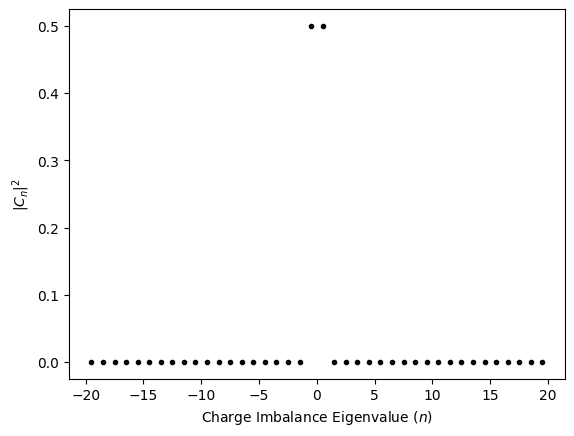

In [2]:
# Plot the coefficients of the eigenvectors, only the middle m
m = 20
x = (n-1)/2 - jnp.arange(n)

#normalize the coefficients
coeffs = (coeffs / jnp.sqrt(jnp.sum(coeffs**2)))**2

plt.plot(x[n//2-m:n//2+m],coeffs[n//2-m:n//2+m],".",color="black")
plt.xlabel(r"Charge Imbalance Eigenvalue ($n$)")
plt.ylabel(r"$|C_n|^2$")
plt.show()

## 2. Left and Right Modes

(<Figure size 800x800 with 2 Axes>,
 <Axes3D: title={'center': 'Right Mode'}>,
 <mpl_toolkits.mplot3d.art3d.Path3DCollection at 0x1521400f4190>)

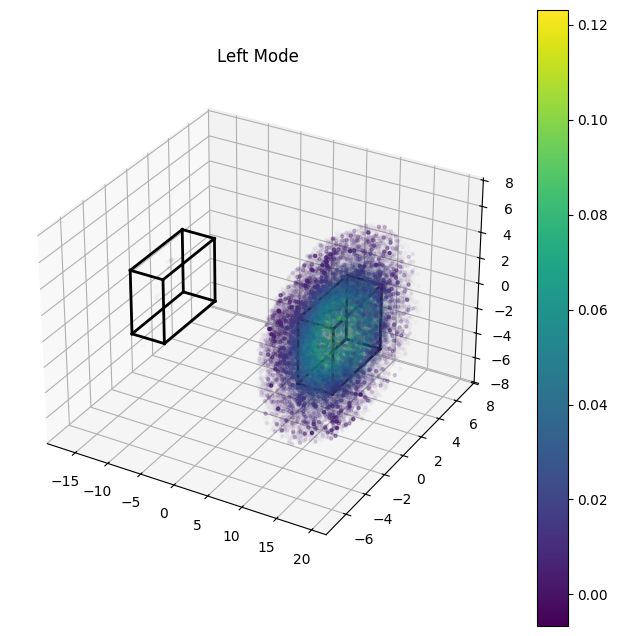

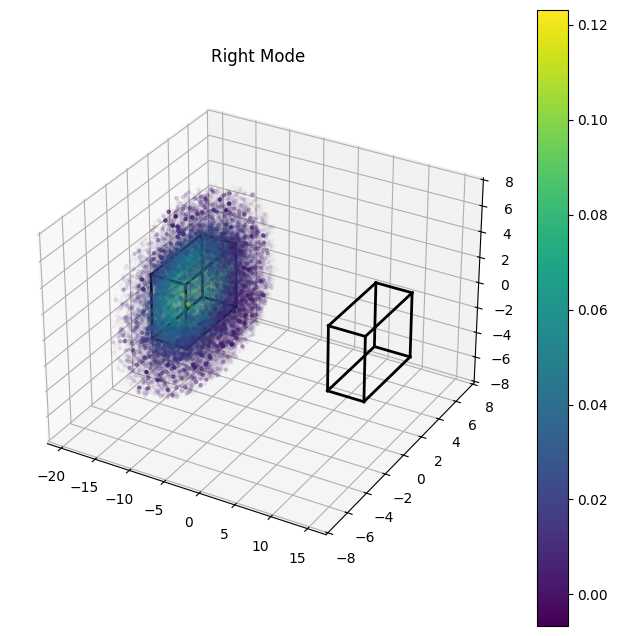

: 

In [ ]:
threshold = 0.003
max_points = 90000
prism_centers = [centerLeft,centerRight]
prism_side_lengths = [(sidelenX, sidelenY, sidelenZ),(sidelenX, sidelenY, sidelenZ)]
wire_color = "black"
wire_linewidth = 2.0

# LEFT mode
femsystem.plot_interior_at_quad_3d_heatmap(u_left_interior, plot_title="Left Mode", max_points=max_points,value_threshold=threshold,    
    prism_centers=prism_centers,
    prism_side_lengths=prism_side_lengths,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth
)

# RIGHT mode
femsystem.plot_interior_at_quad_3d_heatmap(u_right_interior, plot_title="Right Mode", max_points=max_points,value_threshold=threshold,    
    prism_centers=prism_centers,
    prism_side_lengths=prism_side_lengths,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth
)